# Model A: Identifying CIELAB Shade Leveraging Image Clustering


In this notebook, I explore a method for identifying CIELAB color shades in images using image clustering techniques. By leveraging the perceptual uniformity of the CIELAB color space, I aim to achieve more accurate color identification and analysis, which is crucial for makeup where precise color matching is required. This approach allows me to cluster and analyze images based on their color distributions, providing a robust framework for identifying and categorizing shades in a way that aligns with human visual perception.

First, I apply a k-means clustering algorithm to two test images to extract the colors of each cluster, determine the average color across clusters, and identify the peak (most frequent) color.

Next, I scale this approach to the entire dataset, beginning with a training set of images. I validate the algorithm's performance using a validation set, iteratively refining the model to minimize the distance between the color retrieve and the 'ground truth' color.

Finally, I evaluate the optimized algorithm on a test set to assess its effectiveness.



# Libraries

In [67]:
from getpass import getpass
from warnings import simplefilter
import binascii
import glob
import os
import requests
import struct
import urllib
import ast

from PIL import Image
from skimage import color
from skimage.color import deltaE_ciede2000
from skimage.color import rgb2lab, lab2rgb
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.cluster
import scipy.misc
import seaborn as sns

# Setup

In [68]:
import os

BASE = os.path.abspath('../data')
IMGS = os.path.join(BASE, 'img', 'original')
DATA = os.path.join(BASE, 'processed')
RANDOM_SEED = 42
CIELAB_WHITE = np.array([100, 0, 0])
CIELAB_BLACK = np.array([0, 0, 0])

# Data

## Reading and Cleaning Data

I read a table with metadata for each image, including the image filename. I then remove a corrupted file identified during exploratory data analysis (`mac_smoosh_S7GR08.jpg`) and images that were unavailable (returned 404 or 403 errors).

In [69]:
df = pd.read_csv(f'{DATA}/products_with_images.csv')
df.shape

(9167, 21)

In [70]:
df = df[df.img_name != 'mac_smoosh_S7GR08.jpg']
df = df[~df.img_name.isin(['404', '403'])]
df = df.reset_index(drop=True)
df.shape

(9167, 21)

## Train, Validation, and Test Sets

I split the data into training (60%), validation (20%), and test (20%) sets. The training set is used to develop the algorithm and select hyperparameters. The validation set is used to evaluate and iteratively improve performance. The test set is held out until final evaluation.

In [71]:
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=RANDOM_SEED)
validation_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED)

print(f'Training:   {len(train_df)} images')
print(f'Validation: {len(validation_df)} images')
print(f'Test:       {len(test_df)} images')

Training:   5500 images
Validation: 1833 images
Test:       1834 images


# Choosing the Number of Clusters k

I select k using the elbow method on a sample of training images. For each k, I compute the mean inertia (within-cluster sum of squares) across 150 sampled training images. I then apply the second derivative to the inertia curve to automatically detect the elbow — the point where the rate of improvement flattens out most sharply.

In [72]:
from sklearn.cluster import KMeans

def compute_inertia_for_image(image_path, k_range=range(2, 9)):
    try:
        im = Image.open(image_path).convert('RGB')
        im = im.resize((150, 150))
        ar = np.asarray(im).reshape(-1, 3).astype(float)
        return {
            k: KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(ar).inertia_
            for k in k_range
        }
    except Exception:
        return {}

In [73]:
K_RANGE = range(2, 9)
sample_train = train_df.sample(n=min(150, len(train_df)), random_state=RANDOM_SEED)

all_inertias = {k: [] for k in K_RANGE}
for _, row in sample_train.iterrows():
    path = f'{IMGS}/{row.img_name}'
    result = compute_inertia_for_image(path)
    for k, inertia in result.items():
        all_inertias[k].append(inertia)

mean_inertia = np.array([np.mean(all_inertias[k]) for k in K_RANGE])

/Users/connie/dev/lipstick_color_extraction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/connie/dev/lipstick_color_extraction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/connie/dev/lipstick_color_extraction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/connie/dev/lipstick_color_extraction/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/connie/dev/lipstick_color_extraction/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/connie/dev/lipstick_color_extraction/.venv/lib/python3.9/si

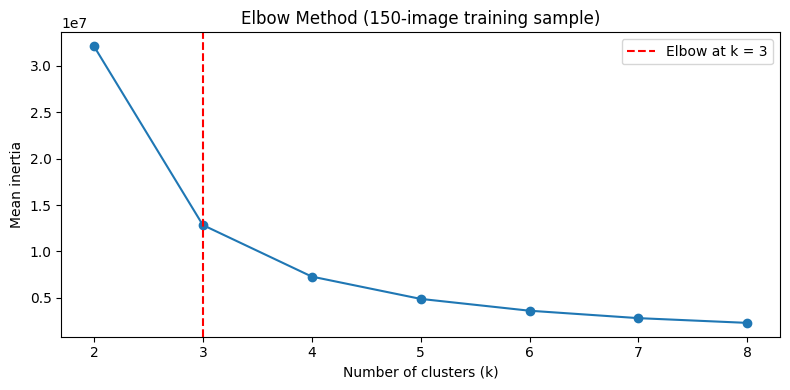

Optimal number of clusters: 3


In [74]:
d2 = np.diff(np.diff(mean_inertia))
NUM_CLUSTERS = list(K_RANGE)[np.argmax(d2) + 1]

plt.figure(figsize=(8, 4))
plt.plot(list(K_RANGE), mean_inertia, marker='o')
plt.axvline(x=NUM_CLUSTERS, color='red', linestyle='--', label=f'Elbow at k = {NUM_CLUSTERS}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Mean inertia')
plt.title('Elbow Method (150-image training sample)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Optimal number of clusters: {NUM_CLUSTERS}')

# Algorithm

## `analyze_image_colors`

The function applies k-means clustering to an image and returns the mean and peak CIELAB colors, excluding clusters that are too close to black or white (common backgrounds and packaging colors).

Key design decisions:
- `Image.convert('RGB')` handles grayscale, PNG, and RGBA images uniformly before any processing
- All cluster centers are converted to LAB before filtering, so black/white detection is perceptually accurate
- If all clusters are filtered out (rare edge case), the function falls back to using all clusters
- Returns `(mean_lab, peak_lab)`: mean across non-black/white clusters, and the most frequent non-black/white cluster

In [75]:
BLACK_WHITE_THRESHOLD = 10  # Delta E threshold for filtering black/white clusters

def analyze_image_colors(image_path, num_clusters=NUM_CLUSTERS):
    im = Image.open(image_path).convert('RGB')
    im = im.resize((150, 150))
    ar = np.asarray(im).reshape(-1, 3).astype(float)

    codes, _ = scipy.cluster.vq.kmeans(ar, num_clusters)
    labels, _ = scipy.cluster.vq.vq(ar, codes)
    counts = np.bincount(labels)

    # Convert all cluster centers to LAB
    codes_lab = np.array([rgb2lab([[c / 255.0]])[0][0] for c in codes])

    # Filter clusters too close to black or white
    mask = np.array([
        deltaE_ciede2000(lab, CIELAB_WHITE) >= BLACK_WHITE_THRESHOLD and
        deltaE_ciede2000(lab, CIELAB_BLACK) >= BLACK_WHITE_THRESHOLD
        for lab in codes_lab
    ])

    if not mask.any():
        mask = np.ones(len(codes), dtype=bool)

    filtered_lab = codes_lab[mask]
    filtered_counts = counts[mask]

    mean_lab = np.mean(filtered_lab, axis=0)
    peak_lab = filtered_lab[np.argmax(filtered_counts)]

    return mean_lab, peak_lab

# Applying the Algorithm to All Images

I apply `analyze_image_colors` to every image and store the mean and peak CIELAB colors back into the dataframe. Images that fail to process (corrupted files, read errors) are skipped and left as NaN.

In [ ]:
df['mean_lab'] = pd.Series(dtype='object')
df['peak_lab'] = pd.Series(dtype='object')
processing_errors = {}

for i in range(len(df)):
    path = f'{IMGS}/{df.img_name[i]}'
    try:
        mean_lab, peak_lab = analyze_image_colors(path)
        if np.any(np.isnan(mean_lab)) or np.any(np.isnan(peak_lab)):
            processing_errors[df.img_name[i]] = 'SilentFailure: NaN in output'
        else:
            df.at[i, 'mean_lab'] = list(mean_lab)
            df.at[i, 'peak_lab'] = list(peak_lab)
    except Exception as e:
        processing_errors[df.img_name[i]] = type(e).__name__ + ': ' + str(e)

print(f'Processed:  {df.mean_lab.notna().sum()} / {len(df)} images')
print(f'Failed:     {len(processing_errors)} images')

In [ ]:
error_summary = pd.Series(processing_errors.values()).value_counts().reset_index()
error_summary.columns = ['error', 'count']
print(error_summary.to_string(index=False))

                                                                                                                                                                                              error  count
                                                                      FileNotFoundError: [Errno 2] No such file or directory: '/Users/connie/dev/lipstick_color_extraction/data/img/original/error'      1
                              UnidentifiedImageError: cannot identify image file '/Users/connie/dev/lipstick_color_extraction/data/img/original/lipstick__etude__fixing_tint_bar__5_mauve_pink.jpg'      1
           UnidentifiedImageError: cannot identify image file '/Users/connie/dev/lipstick_color_extraction/data/img/original/lipstick__etude__not_bad_color_lasting_glow_stick__08_muted_brown.jpg'      1
            UnidentifiedImageError: cannot identify image file '/Users/connie/dev/lipstick_color_extraction/data/img/original/lipstick__etude__not_bad_color_lasting_glow_stick__07_rosy_tau

In [ ]:
# Show a sample of failed images and whether they exist on disk
sample_errors = list(processing_errors.items())[:10]
for name, err in sample_errors:
    exists = os.path.exists(f'{IMGS}/{name}')
    print(f'  [{"exists" if exists else "MISSING"}] {name}: {err}')

  [MISSING] error: FileNotFoundError: [Errno 2] No such file or directory: '/Users/connie/dev/lipstick_color_extraction/data/img/original/error'
  [MISSING] 400: FileNotFoundError: [Errno 2] No such file or directory: '/Users/connie/dev/lipstick_color_extraction/data/img/original/400'
  [exists] lipstick__bobbi_brown__luxe_lipstick__pale_mauve.jpg: OSError: image file is truncated (5 bytes not processed)
  [exists] lipstick__bossy_cosmetics__bullet_lipstick__experienced.png: UnidentifiedImageError: cannot identify image file '/Users/connie/dev/lipstick_color_extraction/data/img/original/lipstick__bossy_cosmetics__bullet_lipstick__experienced.png'
  [exists] lipstick__bossy_cosmetics__bullet_lipstick__graceful.jpg: UnidentifiedImageError: cannot identify image file '/Users/connie/dev/lipstick_color_extraction/data/img/original/lipstick__bossy_cosmetics__bullet_lipstick__graceful.jpg'
  [exists] lipstick__bourjois__rouge_edition_velvet_liquid_lipstick__02_frambourjoise.jpg: UnidentifiedI

In [ ]:
pd.Series(processing_errors.values()).str.split(':').str[0].value_counts()

UnidentifiedImageError    61
FileNotFoundError          7
OSError                    1
Name: count, dtype: int64

In [ ]:
print(f'Processed: {df.mean_lab.notna().sum()} / {len(df)} images')
df[['img_name', 'mean_lab', 'peak_lab']].head()

Processed: 9440 / 9715 images


,img_name,mean_lab,peak_lab
0,lipstick__100_pure__fruit_pigmented_cocoa_butt...,"[40.58963596573125, 41.09321010690718, 20.9225...","[29.48216263917262, 43.484803467777084, 25.694..."
1,lipstick__100_pure__fruit_pigmented_cocoa_butt...,"[66.45574201609065, 5.787338862391634, 4.26156...","[55.02681951842405, 9.954915940441511, 7.11583..."
2,lipstick__100_pure__fruit_pigmented_cocoa_butt...,"[67.75777338335622, 6.152069374639746, 4.27060...","[56.858775685132, 10.885577428991876, 7.310250..."
3,lipstick__100_pure__fruit_pigmented_cocoa_butt...,"[67.58278821158814, 6.129206269613663, 3.73045...","[56.518443199395506, 10.857820255668782, 6.308..."
4,lipstick__100_pure__fruit_pigmented_lip_glaze_...,"[58.95405015679518, 14.72729488178025, 3.24391...","[76.82051593626176, 0.9852168844572962, -0.872..."


### Save Results

In [ ]:
df.to_csv(f'{DATA}/products_clustered.csv', index=False)